# First Black Hole Image — Cinematic Educational Video Notebook

This notebook is modeled after the uploaded **Big Bang cinematic shorts notebook**, but rebuilt for one detailed topic:

> **How the first image of a black hole was taken — M87\***.

It generates a vertical educational explainer video with:

- cinematic procedural space backgrounds
- animated M87\* accretion-ring visuals
- Earth-sized telescope / VLBI network diagrams
- wavefront capture, atomic-clock sync, hard-drive shipment visuals
- correlation, calibration, u-v coverage, and image-reconstruction explainers
- glowing title cards, lower-third captions, scene transitions, and a progress bar

**Outputs**

- `First_Black_Hole_Image_Cinematic_Explainer.mp4`
- `First_Black_Hole_Image_Storyboard.png`

Run the cells from top to bottom. Start with `DRAFT_MODE = True` for a fast preview, then switch it off for a sharper final export.


In [ ]:
# In a fresh Colab/Jupyter environment, uncomment this line:
# %pip install -U numpy pillow imageio imageio-ffmpeg tqdm


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import random
import textwrap
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import imageio.v2 as imageio

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

# ==========================
# Render settings
# ==========================
OUT_DIR = Path("first_black_hole_image_output")
OUT_DIR.mkdir(exist_ok=True)

DRAFT_MODE = True  # True = faster preview. False = sharper final render.

if DRAFT_MODE:
    W, H = 540, 960
    FPS = 18
else:
    W, H = 720, 1280
    FPS = 24

VIDEO_SECONDS = 92.0
NFRAMES = int(VIDEO_SECONDS * FPS)

VIDEO_NAME = OUT_DIR / "First_Black_Hole_Image_Cinematic_Explainer.mp4"
STORYBOARD_NAME = OUT_DIR / "First_Black_Hole_Image_Storyboard.png"

SEED = 87
random.seed(SEED)
np.random.seed(SEED)

# ==========================
# Fact notes used in the narration
# ==========================
FACT_NOTES = [
    "The first black-hole image was released on April 10, 2019 by the Event Horizon Telescope Collaboration.",
    "The target was M87*, the supermassive black hole at the center of Messier 87, about 55 million light-years away.",
    "The inferred black-hole mass is about 6.5 billion solar masses.",
    "The 2017 EHT campaign observed at about 1.3 mm wavelength using very-long-baseline interferometry.",
    "VLBI combines radio telescopes across Earth to synthesize an Earth-sized telescope.",
    "Each telescope recorded signals with hydrogen-maser atomic clocks; petabytes of data were physically shipped for correlation.",
    "The final image was reconstructed from sparse Fourier-domain data using independent imaging teams and methods such as CLEAN and regularized maximum likelihood.",
]

SOURCES = {
    "EHT 2019 press release": "https://eventhorizontelescope.org/press-release-april-10-2019-astronomers-capture-first-image-black-hole",
    "NASA image resource": "https://science.nasa.gov/resource/first-image-of-a-black-hole/",
    "NASA/JPL explainer": "https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-scientists-captured-the-first-image-of-a-black-hole/",
    "EHT science overview": "https://eventhorizontelescope.org/science",
    "EHT Results II — Array and Instrumentation": "https://arxiv.org/abs/1906.11239",
    "EHT Results III — Data Processing and Calibration": "https://arxiv.org/abs/1906.11240",
    "EHT Results IV — Imaging": "https://arxiv.org/abs/1906.11241",
}

# ==========================
# Scene plan: detailed vertical explainer
# ==========================
SCENES = [
    {
        "start": 0.0, "end": 6.5, "kind": "hook",
        "eyebrow": "APRIL 10, 2019",
        "title": "The first black-hole image",
        "caption": "It was not a normal photograph. It was a planet-sized measurement turned into an image."
    },
    {
        "start": 6.5, "end": 15.0, "kind": "target",
        "eyebrow": "TARGET: M87*",
        "title": "A monster in a distant galaxy",
        "caption": "The target was M87*, about 55 million light-years away, with a mass near 6.5 billion Suns."
    },
    {
        "start": 15.0, "end": 24.0, "kind": "scale",
        "eyebrow": "THE HARD PART",
        "title": "The shadow is incredibly tiny",
        "caption": "On the sky, the ring is only tens of microarcseconds wide — far too small for one telescope."
    },
    {
        "start": 24.0, "end": 34.0, "kind": "array",
        "eyebrow": "THE TRICK",
        "title": "Use Earth as the telescope",
        "caption": "The Event Horizon Telescope linked radio observatories across the globe using VLBI."
    },
    {
        "start": 34.0, "end": 43.0, "kind": "wave",
        "eyebrow": "WHAT THEY RECORDED",
        "title": "Radio waves, not visible light",
        "caption": "At 1.3 mm wavelength, each dish caught a tiny slice of the same wavefront."
    },
    {
        "start": 43.0, "end": 52.0, "kind": "clock",
        "eyebrow": "TIME STAMPS",
        "title": "Atomic clocks kept every site in sync",
        "caption": "Hydrogen masers let each telescope label its data precisely enough to combine it later."
    },
    {
        "start": 52.0, "end": 61.5, "kind": "data",
        "eyebrow": "THE DATA",
        "title": "Petabytes on hard drives",
        "caption": "The raw recordings were too large for easy internet transfer, so disks traveled to correlators."
    },
    {
        "start": 61.5, "end": 71.0, "kind": "correlation",
        "eyebrow": "CORRELATION",
        "title": "Pairs of telescopes became baselines",
        "caption": "Computers matched signals from every pair, extracting interference patterns called visibilities."
    },
    {
        "start": 71.0, "end": 80.5, "kind": "uv",
        "eyebrow": "MISSING PIECES",
        "title": "Earth rotation filled in the puzzle",
        "caption": "Each baseline sampled one Fourier component. As Earth turned, the coverage slowly grew."
    },
    {
        "start": 80.5, "end": 87.5, "kind": "reconstruct",
        "eyebrow": "IMAGING",
        "title": "The image was reconstructed",
        "caption": "Independent teams used different methods and checked that the same ring appeared again and again."
    },
    {
        "start": 87.5, "end": 92.0, "kind": "meaning",
        "eyebrow": "WHAT YOU SEE",
        "title": "A shadow surrounded by hot plasma",
        "caption": "The dark center is the black-hole shadow; the bright crescent is light bent by extreme gravity."
    },
]


In [2]:
# ==========================
# Fonts, easing, layout helpers
# ==========================
def font_path(bold: bool = False) -> str | None:
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        "/System/Library/Fonts/Supplemental/Arial Bold.ttf" if bold else "/System/Library/Fonts/Supplemental/Arial.ttf",
        "/Library/Fonts/Arial Bold.ttf" if bold else "/Library/Fonts/Arial.ttf",
    ]
    for p in candidates:
        if p and Path(p).exists():
            return p
    return None

def load_font(size: int, bold: bool = False):
    p = font_path(bold)
    if p:
        return ImageFont.truetype(p, size)
    return ImageFont.load_default()

FONT_EYEBROW = load_font(max(16, W // 31), True)
FONT_TITLE = load_font(max(42, W // 8), True)
FONT_TITLE_SMALL = load_font(max(32, W // 11), True)
FONT_CAPTION = load_font(max(23, W // 24), False)
FONT_LABEL = load_font(max(15, W // 37), True)
FONT_TINY = load_font(max(12, W // 46), False)

COLORS = {
    "bg0": (3, 4, 12),
    "bg1": (7, 12, 30),
    "orange": (255, 138, 48),
    "gold": (255, 204, 101),
    "cyan": (105, 214, 255),
    "blue": (70, 130, 255),
    "purple": (163, 107, 255),
    "white": (245, 248, 255),
    "muted": (170, 185, 210),
    "black": (0, 0, 0),
}

def clamp(x: float, lo: float = 0.0, hi: float = 1.0) -> float:
    return max(lo, min(hi, x))

def lerp(a: float, b: float, u: float) -> float:
    return a + (b - a) * u

def smoothstep(edge0: float, edge1: float, x: float) -> float:
    x = clamp((x - edge0) / max(1e-9, edge1 - edge0))
    return x * x * (3 - 2 * x)

def ease_in_out(u: float) -> float:
    u = clamp(u)
    return 0.5 - 0.5 * math.cos(math.pi * u)

def ease_out(u: float) -> float:
    u = clamp(u)
    return 1 - (1 - u) ** 3

def text_size(draw: ImageDraw.ImageDraw, text: str, font) -> tuple[int, int]:
    box = draw.textbbox((0, 0), text, font=font)
    return box[2] - box[0], box[3] - box[1]

def wrap_lines(draw: ImageDraw.ImageDraw, text: str, font, max_width: int) -> list[str]:
    words = text.split()
    lines, line = [], ""
    for word in words:
        test = (line + " " + word).strip()
        if text_size(draw, test, font)[0] <= max_width:
            line = test
        else:
            if line:
                lines.append(line)
            line = word
    if line:
        lines.append(line)
    return lines

def draw_glow_text(
    img: Image.Image,
    xy: tuple[int, int],
    text: str,
    font,
    fill=(255, 255, 255, 255),
    anchor: str = "mm",
    glow=(255, 130, 35, 120),
    blur: int = 10,
    stroke: int = 0,
):
    layer = Image.new("RGBA", img.size, (0, 0, 0, 0))
    d = ImageDraw.Draw(layer)
    d.text(xy, text, font=font, fill=glow, anchor=anchor, stroke_width=stroke, stroke_fill=(0, 0, 0, 160))
    img.alpha_composite(layer.filter(ImageFilter.GaussianBlur(blur)))
    d = ImageDraw.Draw(img)
    d.text(xy, text, font=font, fill=fill, anchor=anchor, stroke_width=stroke, stroke_fill=(0, 0, 0, 200))

def draw_wrapped_centered(img: Image.Image, text: str, y: int, font, max_width: int, fill=(235, 242, 255, 235), line_gap: int = 8):
    d = ImageDraw.Draw(img)
    lines = wrap_lines(d, text, font, max_width)
    heights = [text_size(d, line, font)[1] for line in lines]
    total_h = sum(heights) + line_gap * (len(lines) - 1)
    yy = y - total_h // 2
    for line, h in zip(lines, heights):
        tw, _ = text_size(d, line, font)
        d.text(((W - tw) // 2, yy), line, font=font, fill=fill)
        yy += h + line_gap

def draw_panel(img: Image.Image, x0: int, y0: int, x1: int, y1: int, alpha: int = 95):
    panel = Image.new("RGBA", img.size, (0, 0, 0, 0))
    d = ImageDraw.Draw(panel, "RGBA")
    d.rounded_rectangle([x0, y0, x1, y1], radius=max(12, W // 34), fill=(8, 12, 24, alpha), outline=(120, 160, 255, 55), width=1)
    img.alpha_composite(panel)

def draw_scene_text(img: Image.Image, scene: dict, local: float):
    fade = smoothstep(0.0, 0.13, local) * (1 - smoothstep(0.88, 1.0, local))
    a = int(255 * fade)
    if a <= 0:
        return
    d = ImageDraw.Draw(img, "RGBA")

    y_top = int(H * 0.08)
    eyebrow = scene["eyebrow"].upper()
    ew, eh = text_size(d, eyebrow, FONT_EYEBROW)
    d.rounded_rectangle(
        [(W - ew) // 2 - 15, y_top - 8, (W + ew) // 2 + 15, y_top + eh + 10],
        radius=14,
        fill=(15, 22, 44, int(150 * fade)),
        outline=(255, 168, 70, int(90 * fade)),
    )
    d.text(((W - ew) // 2, y_top), eyebrow, font=FONT_EYEBROW, fill=(255, 210, 120, a))

    title_font = FONT_TITLE if len(scene["title"]) <= 24 else FONT_TITLE_SMALL
    title_lines = wrap_lines(d, scene["title"], title_font, int(W * 0.88))
    yy = int(H * 0.135)
    for line in title_lines:
        tw, th = text_size(d, line, title_font)
        draw_glow_text(
            img,
            (W // 2, yy + th // 2),
            line,
            title_font,
            fill=(255, 255, 255, a),
            glow=(255, 120, 35, int(110 * fade)),
            blur=12,
            stroke=1,
        )
        yy += th + 7

    # lower-third caption
    cap_h = int(H * 0.145)
    y0 = H - cap_h - int(H * 0.07)
    draw_panel(img, int(W * 0.055), y0, int(W * 0.945), y0 + cap_h, alpha=int(118 * fade))
    draw_wrapped_centered(
        img,
        scene["caption"],
        y0 + cap_h // 2,
        FONT_CAPTION,
        int(W * 0.79),
        fill=(230, 240, 255, a),
        line_gap=8,
    )

def draw_progress(img: Image.Image, t: float):
    d = ImageDraw.Draw(img, "RGBA")
    margin = int(W * 0.08)
    y = H - int(H * 0.035)
    d.rounded_rectangle([margin, y, W - margin, y + 5], radius=3, fill=(255, 255, 255, 35))
    x = margin + int((W - 2 * margin) * clamp(t / VIDEO_SECONDS))
    d.rounded_rectangle([margin, y, x, y + 5], radius=3, fill=(255, 160, 55, 210))

def add_vignette(img: Image.Image, strength: float = 0.65):
    yy, xx = np.mgrid[0:H, 0:W]
    cx, cy = W / 2, H / 2
    r = np.sqrt(((xx - cx) / (W * 0.62)) ** 2 + ((yy - cy) / (H * 0.62)) ** 2)
    v = np.clip((r - 0.45) / 0.75, 0, 1) ** 1.5
    overlay = np.zeros((H, W, 4), dtype=np.uint8)
    overlay[..., 3] = (v * 255 * strength).astype(np.uint8)
    img.alpha_composite(Image.fromarray(overlay, "RGBA"))

def add_grain(img: Image.Image, amount: int = 10):
    if amount <= 0:
        return
    arr = np.array(img).astype(np.int16)
    rng = np.random.default_rng(SEED + 999)
    noise = rng.normal(0, amount, arr.shape[:2] + (1,))
    arr[..., :3] = np.clip(arr[..., :3] + noise, 0, 255)
    img.paste(Image.fromarray(arr.astype(np.uint8), "RGBA"))


In [8]:
# ==========================
# Deterministic procedural assets
# ==========================
rng = np.random.default_rng(SEED)

STAR_COUNT = 700 if DRAFT_MODE else 1100
STAR_X = rng.random(STAR_COUNT) * W
STAR_Y = rng.random(STAR_COUNT) * H
STAR_Z = rng.random(STAR_COUNT) * 1.0 + 0.25
STAR_SIZE = rng.random(STAR_COUNT) * 1.7 + 0.25
STAR_TWINKLE = rng.random(STAR_COUNT) * math.tau

# Simplified coordinates for major 2017 EHT observing sites, mapped to a stylized globe.
EHT_SITES = [
    ("ALMA", -67.75, -23.02),
    ("APEX", -67.76, -23.01),
    ("LMT", -97.31, 18.99),
    ("SMT", -109.89, 32.70),
    ("SMA", -155.48, 19.82),
    ("JCMT", -155.48, 19.82),
    ("IRAM", -3.39, 37.07),
    ("SPT", 0.00, -90.00),
]

def project_site(lon: float, lat: float, rot: float = 0.0, cx: int | None = None, cy: int | None = None, r: int | None = None):
    """Orthographic-ish projection for a decorative rotating Earth."""
    if cx is None: cx = W // 2
    if cy is None: cy = int(H * 0.48)
    if r is None: r = int(W * 0.38)
    lonr = math.radians(lon + rot)
    latr = math.radians(lat)
    x = math.cos(latr) * math.sin(lonr)
    y = -math.sin(latr)
    z = math.cos(latr) * math.cos(lonr)
    return cx + int(x * r), cy + int(y * r), z

def draw_starfield(img: Image.Image, t: float, speed: float = 0.12, alpha: int = 180):
    d = ImageDraw.Draw(img, "RGBA")
    for i in range(STAR_COUNT):
        tw = 0.45 + 0.55 * math.sin(t * 1.8 + STAR_TWINKLE[i])
        y = (STAR_Y[i] + t * speed * H * STAR_Z[i]) % H
        x = STAR_X[i]
        s = STAR_SIZE[i] * (0.7 + 0.5 * tw)
        a = int(alpha * (0.3 + 0.7 * tw) / STAR_Z[i])
        d.ellipse([x - s, y - s, x + s, y + s], fill=(210, 225, 255, max(25, min(255, a))))

def nebula_background(t: float, hue_shift: float = 0.0) -> Image.Image:
    """Cheap animated cloudy background using low-res noise upscaled."""
    small_w, small_h = max(72, W // 8), max(128, H // 8)
    local_rng = np.random.default_rng(SEED + int(t * 7))
    noise = local_rng.normal(0.5, 0.22, (small_h, small_w))
    yy, xx = np.mgrid[0:small_h, 0:small_w]
    blobs = (
        0.45 * np.sin(xx * 0.10 + t * 0.50 + hue_shift)
        + 0.35 * np.sin(yy * 0.08 - t * 0.36)
        + 0.25 * np.sin((xx + yy) * 0.055 + t * 0.28)
    )
    v = np.clip(noise * 0.35 + blobs * 0.23 + 0.45, 0, 1)
    arr = np.zeros((small_h, small_w, 3), dtype=np.uint8)
    arr[..., 0] = np.clip(6 + 50 * v + 45 * np.maximum(0, np.sin(hue_shift)), 0, 255)
    arr[..., 1] = np.clip(8 + 28 * v + 28 * np.maximum(0, np.cos(hue_shift + 1.2)), 0, 255)
    arr[..., 2] = np.clip(18 + 80 * v + 55 * np.maximum(0, np.sin(hue_shift + 2.0)), 0, 255)
    im = Image.fromarray(arr, "RGB").resize((W, H), Image.Resampling.BICUBIC).filter(ImageFilter.GaussianBlur(3))
    im = im.convert("RGBA")
    draw_starfield(im, t, speed=0.035, alpha=150)
    return im

def draw_accretion_ring(img: Image.Image, cx: int, cy: int, radius: int, t: float, tilt: float = 0.72, glow_alpha: int = 210, show_labels: bool = False):
    """Stylized M87* ring: hot plasma crescent + dark shadow."""
    layer = Image.new("RGBA", img.size, (0, 0, 0, 0))
    d = ImageDraw.Draw(layer, "RGBA")

    # Soft outer glow
    for k in range(9, 0, -1):
        rr = radius + k * int(radius * 0.08)
        alpha = int(glow_alpha * 0.045 * k)
        d.ellipse([cx - rr, cy - int(rr * tilt), cx + rr, cy + int(rr * tilt)],
                  outline=(255, 112, 31, alpha), width=max(2, radius // 22))

    # Ring made of many short bright arcs / knots
    for j in range(90):
        a0 = (j / 90) * math.tau
        phase = (a0 + t * 0.55) % math.tau
        # southern side brighter, like M87* first image
        bright = 0.35 + 0.65 * smoothstep(-0.15, 0.9, math.sin(phase))
        bright *= 0.75 + 0.25 * math.sin(6 * phase + t * 2.0)
        rj = radius * (0.94 + 0.055 * math.sin(3 * phase + 0.8))
        x = cx + math.cos(phase) * rj
        y = cy + math.sin(phase) * rj * tilt
        s = max(3, int(radius * (0.038 + bright * 0.035)))
        col = (
            int(210 + 45 * bright),
            int(74 + 140 * bright),
            int(22 + 25 * bright),
            int(75 + 180 * bright),
        )
        d.ellipse([x - s, y - s, x + s, y + s], fill=col)

    # dark shadow and inner rim
    shadow_r = int(radius * 0.58)
    d.ellipse([cx - shadow_r, cy - int(shadow_r * tilt), cx + shadow_r, cy + int(shadow_r * tilt)],
              fill=(0, 0, 0, 238))
    d.ellipse([cx - shadow_r, cy - int(shadow_r * tilt), cx + shadow_r, cy + int(shadow_r * tilt)],
              outline=(255, 180, 88, 70), width=max(1, radius // 34))
    img.alpha_composite(layer.filter(ImageFilter.GaussianBlur(max(1, radius // 80))))

    # sharper pass
    sharp = Image.new("RGBA", img.size, (0, 0, 0, 0))
    sd = ImageDraw.Draw(sharp, "RGBA")
    for j in range(60):
        phase = (j / 60) * math.tau + t * 0.4
        bright = 0.25 + 0.75 * smoothstep(-0.1, 0.95, math.sin(phase))
        rj = radius * (0.98 + 0.025 * math.sin(4 * phase))
        x = cx + math.cos(phase) * rj
        y = cy + math.sin(phase) * rj * tilt
        s = max(2, int(radius * (0.022 + bright * 0.024)))
        sd.ellipse([x - s, y - s, x + s, y + s],
                   fill=(255, int(116 + 106 * bright), 38, int(60 + 165 * bright)))
    shadow_r2 = int(radius * 0.54)
    sd.ellipse([cx - shadow_r2, cy - int(shadow_r2 * tilt), cx + shadow_r2, cy + int(shadow_r2 * tilt)],
              fill=(0, 0, 0, 235))
    img.alpha_composite(sharp)

    if show_labels:
        d = ImageDraw.Draw(img, "RGBA")
        d.line([cx + int(radius * 0.35), cy - int(radius * 0.6), cx + int(radius * 0.95), cy - int(radius * 1.0)], fill=(255, 210, 120, 170), width=2)
        d.text((cx + int(radius * 0.98), cy - int(radius * 1.05)), "hot plasma ring", font=FONT_TINY, fill=(255, 220, 140, 220))
        d.line([cx - int(radius * 0.15), cy + int(radius * 0.05), cx - int(radius * 0.85), cy + int(radius * 0.45)], fill=(150, 200, 255, 160), width=2)
        d.text((cx - int(radius * 1.28), cy + int(radius * 0.47)), "black-hole shadow", font=FONT_TINY, fill=(195, 220, 255, 220))

def draw_radio_dish(img: Image.Image, x: int, y: int, scale: float = 1.0, angle: float = -0.35, alpha: int = 230):
    d = ImageDraw.Draw(img, "RGBA")
    s = scale
    mast = int(34 * s)
    bowl_w = int(58 * s)
    bowl_h = int(25 * s)
    # stand
    d.line([x, y, x, y - mast], fill=(200, 220, 255, alpha), width=max(2, int(3 * s)))
    d.line([x, y - int(4 * s), x - int(20 * s), y + int(22 * s)], fill=(150, 180, 220, alpha), width=max(1, int(2 * s)))
    d.line([x, y - int(4 * s), x + int(20 * s), y + int(22 * s)], fill=(150, 180, 220, alpha), width=max(1, int(2 * s)))
    # dish
    cx = x + int(math.sin(angle) * 18 * s)
    cy = y - mast - int(math.cos(angle) * 5 * s)
    bbox = [cx - bowl_w // 2, cy - bowl_h // 2, cx + bowl_w // 2, cy + bowl_h // 2]
    d.arc(bbox, 190, 350, fill=(230, 240, 255, alpha), width=max(2, int(3 * s)))
    d.line([cx - bowl_w // 2, cy, cx + bowl_w // 2, cy], fill=(110, 160, 220, int(alpha * 0.75)), width=max(1, int(2 * s)))
    d.ellipse([cx - int(3*s), cy - int(3*s), cx + int(3*s), cy + int(3*s)], fill=(255, 210, 100, alpha))

def draw_data_stream(img: Image.Image, p0: tuple[int, int], p1: tuple[int, int], t: float, color=(255, 180, 70), count: int = 16):
    d = ImageDraw.Draw(img, "RGBA")
    x0, y0 = p0
    x1, y1 = p1
    d.line([x0, y0, x1, y1], fill=(120, 160, 255, 60), width=1)
    for i in range(count):
        u = (i / count + t * 0.45) % 1
        x = lerp(x0, x1, u)
        y = lerp(y0, y1, u)
        r = 2 + 2 * math.sin(u * math.pi)
        d.ellipse([x-r, y-r, x+r, y+r], fill=(color[0], color[1], color[2], int(70 + 150 * (1-u))))


In [9]:
# ==========================
# Scene visual functions
# ==========================
def scene_hook(img: Image.Image, t: float, local: float):
    cx, cy = W // 2, int(H * 0.48)
    # Start from a mysterious shadow, then reveal the ring
    zoom = 0.72 + 0.42 * ease_out(local)
    draw_accretion_ring(img, cx, cy, int(W * 0.31 * zoom), t, glow_alpha=int(150 + 80 * local))
    d = ImageDraw.Draw(img, "RGBA")
    # camera / measurement overlay
    scan_y = int(H * (0.28 + 0.34 * ((t * 0.22) % 1)))
    d.line([int(W * 0.12), scan_y, int(W * 0.88), scan_y], fill=(105, 214, 255, 90), width=2)
    for x in range(int(W*0.14), int(W*0.88), max(18, W//22)):
        d.line([x, scan_y - 9, x, scan_y + 9], fill=(105, 214, 255, 65), width=1)
    d.text((int(W*0.07), int(H*0.68)), "not a snapshot", font=FONT_LABEL, fill=(255, 210, 120, int(180 * smoothstep(0.25, 0.65, local))))
    d.text((int(W*0.07), int(H*0.705)), "a reconstructed radio image", font=FONT_LABEL, fill=(190, 220, 255, int(170 * smoothstep(0.38, 0.78, local))))

def scene_target(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # distant galaxy halo
    cx, cy = W // 2, int(H * 0.49)
    halo = Image.new("RGBA", img.size, (0, 0, 0, 0))
    hd = ImageDraw.Draw(halo, "RGBA")
    for k in range(14, 0, -1):
        rr = int(W * (0.11 + 0.025 * k) * (0.8 + 0.25 * ease_out(local)))
        hd.ellipse([cx-rr, cy-int(rr*0.46), cx+rr, cy+int(rr*0.46)],
                   outline=(190, 150, 255, int(10 + k * 6)), width=max(1, int(W*0.006)))
    img.alpha_composite(halo.filter(ImageFilter.GaussianBlur(12)))

    # jet-like beam
    jet = Image.new("RGBA", img.size, (0,0,0,0))
    jd = ImageDraw.Draw(jet, "RGBA")
    for wmul in [1.0, 0.62, 0.35]:
        jd.polygon([
            (cx + int(W*0.02), cy - int(H*0.012)),
            (cx + int(W*0.44), cy - int(H*0.18*wmul)),
            (cx + int(W*0.47), cy - int(H*0.14*wmul)),
            (cx + int(W*0.02), cy + int(H*0.008)),
        ], fill=(115, 160, 255, int(28 * wmul)))
    img.alpha_composite(jet.filter(ImageFilter.GaussianBlur(5)))

    draw_accretion_ring(img, cx, cy, int(W * 0.18), t, glow_alpha=180)
    # fact chips
    chips = [("55 million light-years", 0.18), ("6.5 billion Suns", 0.74)]
    for txt, xfrac in chips:
        a = int(210 * smoothstep(0.25, 0.65, local))
        tw, th = text_size(d, txt, FONT_LABEL)
        x = int(W * xfrac)
        y = int(H * 0.62)
        d.rounded_rectangle([x - tw//2 - 12, y - 8, x + tw//2 + 12, y + th + 10], radius=14, fill=(10, 18, 38, int(128*local)), outline=(255, 180, 90, int(90*local)))
        d.text((x - tw//2, y), txt, font=FONT_LABEL, fill=(245, 248, 255, a))

def scene_scale(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = W // 2, int(H * 0.47)
    # giant angular scale ruler
    draw_accretion_ring(img, cx, cy, int(W * 0.16), t, glow_alpha=180)
    for rr, label, delay in [
        (int(W*0.31), "arcsecond", 0.15),
        (int(W*0.23), "milliarcsecond", 0.35),
        (int(W*0.16), "microarcseconds", 0.55),
    ]:
        a = int(160 * smoothstep(delay, delay+0.28, local))
        d.ellipse([cx-rr, cy-rr, cx+rr, cy+rr], outline=(105, 214, 255, a), width=1)
        d.text((cx + rr + 8, cy - rr//3), label, font=FONT_TINY, fill=(180, 220, 255, a))
    # ruler line for ring diameter
    y = cy + int(W * 0.25)
    x0, x1 = cx - int(W * 0.19), cx + int(W * 0.19)
    a = int(220 * smoothstep(0.35, 0.75, local))
    d.line([x0, y, x1, y], fill=(255, 210, 100, a), width=3)
    d.line([x0, y-12, x0, y+12], fill=(255, 210, 100, a), width=3)
    d.line([x1, y-12, x1, y+12], fill=(255, 210, 100, a), width=3)
    label = "ring diameter ≈ 40 microarcseconds"
    tw, th = text_size(d, label, FONT_LABEL)
    d.text((cx - tw//2, y + 20), label, font=FONT_LABEL, fill=(255, 230, 140, a))

def scene_array(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy, r = W//2, int(H*0.49), int(W*0.35)
    rot = t * 9
    # Earth sphere
    globe = Image.new("RGBA", img.size, (0,0,0,0))
    gd = ImageDraw.Draw(globe, "RGBA")
    for k in range(9, 0, -1):
        rr = r + k * 5
        gd.ellipse([cx-rr, cy-rr, cx+rr, cy+rr], fill=(10, 22, 58, int(8*k)), outline=(95, 165, 255, int(11*k)))
    gd.ellipse([cx-r, cy-r, cx+r, cy+r], fill=(8, 22, 55, 210), outline=(120, 190, 255, 165), width=2)
    # latitude / longitude
    for a in np.linspace(-0.65, 0.65, 5):
        yy = cy + int(a*r)
        gd.ellipse([cx-r, yy-int(r*0.18), cx+r, yy+int(r*0.18)], outline=(75, 125, 190, 45), width=1)
    for a in np.linspace(-0.75, 0.75, 5):
        gd.arc([cx-int(r*abs(math.cos(a))), cy-r, cx+int(r*abs(math.cos(a))), cy+r], 90, 270, fill=(75, 125, 190, 45), width=1)
        gd.arc([cx-int(r*abs(math.cos(a))), cy-r, cx+int(r*abs(math.cos(a))), cy+r], -90, 90, fill=(75, 125, 190, 45), width=1)
    img.alpha_composite(globe)

    points = []
    for name, lon, lat in EHT_SITES:
        x, y, z = project_site(lon, lat, rot=rot, cx=cx, cy=cy, r=r)
        if z > -0.15:
            points.append((x, y, z, name))
    # baselines
    for i in range(len(points)):
        for j in range(i+1, len(points)):
            x0,y0,z0,n0 = points[i]
            x1,y1,z1,n1 = points[j]
            a = int(35 + 65 * min(z0, z1))
            d.line([x0, y0, x1, y1], fill=(255, 170, 70, max(0, a)), width=1)
    for x,y,z,name in points:
        s = 4 + 2 * z
        d.ellipse([x-s, y-s, x+s, y+s], fill=(255, 210, 105, 230), outline=(255,255,255,140))
        if z > 0.2:
            d.text((x+7, y-6), name, font=FONT_TINY, fill=(220,235,255,210))
    # explanatory badge
    badge = "VLBI = very-long-baseline interferometry"
    tw, th = text_size(d, badge, FONT_LABEL)
    yb = int(H*0.68)
    d.rounded_rectangle([(W-tw)//2-12, yb-8, (W+tw)//2+12, yb+th+10], radius=14, fill=(8,12,28,150), outline=(105,214,255,80))
    d.text(((W-tw)//2, yb), badge, font=FONT_LABEL, fill=(225,240,255,220))

def scene_wave(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # incoming radio wavefronts
    for k in range(11):
        x = int(W * (1.05 - ((t * 0.20 + k * 0.12) % 1.25)))
        d.arc([x - W, int(H*0.18), x + W, int(H*0.82)], -45, 45, fill=(105,214,255,55), width=2)
    # dishes
    base_y = int(H * 0.64)
    xs = [int(W*0.18), int(W*0.39), int(W*0.61), int(W*0.82)]
    for i, x in enumerate(xs):
        draw_radio_dish(img, x, base_y + (i%2)*20, scale=0.92, angle=-0.5 + 0.18*math.sin(t+i), alpha=230)
        # little signal line downward
        yy = base_y + (i%2)*20 + 34
        d.rounded_rectangle([x-38, yy, x+38, yy+34], radius=8, fill=(8,12,24,150), outline=(105,214,255,70))
        d.text((x-24, yy+8), "1.3 mm", font=FONT_TINY, fill=(255,230,140,210))
    # photon path / radio caption
    a = int(210 * smoothstep(0.3, 0.72, local))
    d.text((int(W*0.10), int(H*0.43)), "millimeter radio light", font=FONT_LABEL, fill=(210,235,255,a))
    d.line([int(W*0.10), int(H*0.46), int(W*0.78), int(H*0.46)], fill=(105,214,255,a//2), width=1)

def scene_clock(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    centers = [(int(W*0.28), int(H*0.42)), (int(W*0.72), int(H*0.42)), (int(W*0.50), int(H*0.62))]
    labels = ["Chile", "Hawaii", "Spain"]
    for i, (cx, cy) in enumerate(centers):
        d.rounded_rectangle([cx-75, cy-78, cx+75, cy+92], radius=18, fill=(8, 13, 30, 170), outline=(105,214,255,75))
        draw_radio_dish(img, cx, cy+45, scale=0.55, alpha=220)
        # clock face
        rr = 34
        d.ellipse([cx-rr, cy-rr, cx+rr, cy+rr], outline=(245,248,255,190), width=2, fill=(12,22,45,120))
        ang = t * math.tau * 0.8 + i
        d.line([cx, cy, cx + int(math.cos(ang)*rr*0.70), cy + int(math.sin(ang)*rr*0.70)], fill=(255,210,90,230), width=3)
        d.line([cx, cy, cx + int(math.cos(ang*0.37)*rr*0.50), cy + int(math.sin(ang*0.37)*rr*0.50)], fill=(150,220,255,210), width=2)
        d.ellipse([cx-3, cy-3, cx+3, cy+3], fill=(255,255,255,230))
        tw, th = text_size(d, labels[i], FONT_TINY)
        d.text((cx-tw//2, cy+64), labels[i], font=FONT_TINY, fill=(220,235,255,210))
    # sync pulses between clocks
    for i in range(len(centers)):
        p0 = centers[i]
        p1 = centers[(i+1)%len(centers)]
        draw_data_stream(img, p0, p1, t + i*0.2, color=(105,214,255), count=10)
    d.text((int(W*0.16), int(H*0.72)), "hydrogen maser clocks", font=FONT_LABEL, fill=(255,230,140,220))
    d.text((int(W*0.16), int(H*0.75)), "make later combination possible", font=FONT_TINY, fill=(220,235,255,200))

def scene_data(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # hard-drive stacks
    for stack in range(3):
        x0 = int(W * (0.18 + stack * 0.25))
        y0 = int(H * 0.40 + (stack % 2) * 20)
        for j in range(7):
            y = y0 + j * 18
            d.rounded_rectangle([x0, y, x0+105, y+15], radius=4, fill=(20,31,55,220), outline=(105,214,255,70))
            d.rectangle([x0+9, y+4, x0+76, y+7], fill=(85,135,210,100))
            d.ellipse([x0+89, y+4, x0+95, y+10], fill=(255,200,80,200))
        d.text((x0+4, y0-23), f"site {stack+1}", font=FONT_TINY, fill=(220,235,255,190))
    # shipping route
    plane_y = int(H * 0.66)
    d.line([int(W*0.14), plane_y, int(W*0.86), plane_y - int(H*0.06)], fill=(255,180,80,100), width=2)
    px = int(lerp(W*0.14, W*0.86, (t*0.18) % 1))
    py = int(lerp(plane_y, plane_y-int(H*0.06), (t*0.18) % 1))
    d.polygon([(px,py), (px-20,py+8), (px-14,py), (px-20,py-8)], fill=(245,248,255,220))
    d.text((int(W*0.13), int(H*0.72)), "raw recordings → correlator centers", font=FONT_LABEL, fill=(255,230,140,220))
    # data counter
    count_text = "petabytes of data"
    tw, th = text_size(d, count_text, FONT_TITLE_SMALL)
    draw_glow_text(img, (W//2, int(H*0.30)), count_text, FONT_TITLE_SMALL, fill=(255,255,255,235), glow=(105,214,255,90), blur=10, stroke=1)

def scene_correlation(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # two wave traces
    top_y = int(H*0.35)
    for row, color in enumerate([(255,180,70), (105,214,255), (180,120,255)]):
        y = top_y + row * int(H*0.095)
        pts = []
        for x in range(int(W*0.10), int(W*0.90), 5):
            u = (x/W)*math.tau*5 + t*3 + row
            val = math.sin(u) + 0.35*math.sin(2.7*u+row)
            pts.append((x, y + int(val * 16)))
        d.line(pts, fill=(color[0], color[1], color[2], 190), width=2)
        d.text((int(W*0.10), y-32), f"signal {row+1}", font=FONT_TINY, fill=(220,235,255,180))
    # correlation matrix
    x0, y0 = int(W*0.20), int(H*0.66)
    cell = int(W*0.095)
    labels = ["A", "B", "C", "D", "E"]
    for i in range(5):
        for j in range(5):
            phase = math.sin(t*2 + i*0.7 + j*0.55)
            alpha = int(50 + 120*abs(phase))
            fill = (255, 150, 55, alpha) if i != j else (105,214,255,90)
            d.rectangle([x0+i*cell, y0+j*cell, x0+(i+1)*cell-3, y0+(j+1)*cell-3], fill=fill, outline=(255,255,255,25))
    d.text((x0, y0 - 35), "baseline pairs → visibilities", font=FONT_LABEL, fill=(255,230,140,220))

def scene_uv(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    cx, cy = W//2, int(H*0.49)
    # Fourier plane axes
    d.line([int(W*0.12), cy, int(W*0.88), cy], fill=(190,220,255,70), width=1)
    d.line([cx, int(H*0.25), cx, int(H*0.70)], fill=(190,220,255,70), width=1)
    d.text((int(W*0.84), cy+8), "u", font=FONT_TINY, fill=(190,220,255,150))
    d.text((cx+8, int(H*0.25)), "v", font=FONT_TINY, fill=(190,220,255,150))

    # u-v tracks: elliptical arcs that fill over time
    fill_amt = smoothstep(0.05, 0.9, local)
    for k in range(13):
        a = 0.25 + k * 0.06
        b = 0.10 + (k % 6) * 0.035
        rot = k * 0.42 + t * 0.10
        pts = []
        n = int(8 + 70 * fill_amt)
        for m in range(n):
            ang = (m / max(1, n-1)) * math.tau * (0.4 + 0.6*fill_amt) + k
            x = math.cos(ang) * a * W
            y = math.sin(ang) * b * W
            xr = x * math.cos(rot) - y * math.sin(rot)
            yr = x * math.sin(rot) + y * math.cos(rot)
            pts.append((cx + int(xr), cy + int(yr)))
        if len(pts) > 1:
            d.line(pts, fill=(105,214,255,45), width=1)
        for p in pts[::max(1, len(pts)//12)]:
            d.ellipse([p[0]-2, p[1]-2, p[0]+2, p[1]+2], fill=(255,190,80,170))

    # puzzle metaphor
    y = int(H*0.72)
    d.text((int(W*0.11), y), "not pixels yet — measurements of spatial frequencies", font=FONT_TINY, fill=(220,235,255,210))

def scene_reconstruct(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # three independent teams / pipelines converging to same ring
    xs = [int(W*0.25), int(W*0.50), int(W*0.75)]
    methods = ["CLEAN", "RML", "blind team"]
    for i, x in enumerate(xs):
        y = int(H*0.44)
        d.rounded_rectangle([x-int(W*0.16), y-int(W*0.15), x+int(W*0.16), y+int(W*0.15)], radius=16, fill=(8,13,30,150), outline=(105,214,255,60))
        draw_accretion_ring(img, x, y, int(W*(0.075 + 0.018*smoothstep(0.15*i, 0.6+0.08*i, local))), t+i, glow_alpha=135)
        tw, th = text_size(d, methods[i], FONT_TINY)
        d.text((x - tw//2, y + int(W*0.12)), methods[i], font=FONT_TINY, fill=(220,235,255,210))
    # arrows to final
    fy = int(H*0.67)
    for x in xs:
        d.line([x, int(H*0.58), W//2, fy-int(W*0.13)], fill=(255,180,80,80), width=2)
    draw_accretion_ring(img, W//2, fy, int(W*0.14), t, glow_alpha=190)
    label = "same robust ring"
    tw, th = text_size(d, label, FONT_LABEL)
    d.text((W//2-tw//2, fy+int(W*0.18)), label, font=FONT_LABEL, fill=(255,230,140,220))

def scene_meaning(img: Image.Image, t: float, local: float):
    cx, cy = W//2, int(H*0.49)
    draw_accretion_ring(img, cx, cy, int(W*0.30), t, tilt=0.72, glow_alpha=230, show_labels=True)
    d = ImageDraw.Draw(img, "RGBA")
    # final summary bullets
    a = int(225 * smoothstep(0.2, 0.8, local))
    bullets = [
        "gravity bends light into a ring",
        "the center is not empty pixels — it is the shadow",
        "brightness asymmetry reveals moving plasma",
    ]
    y0 = int(H*0.70)
    for i, b in enumerate(bullets):
        yy = y0 + i * int(H*0.035)
        d.ellipse([int(W*0.12)-4, yy+5, int(W*0.12)+4, yy+13], fill=(255,180,80,a))
        d.text((int(W*0.15), yy), b, font=FONT_TINY, fill=(225,240,255,a))


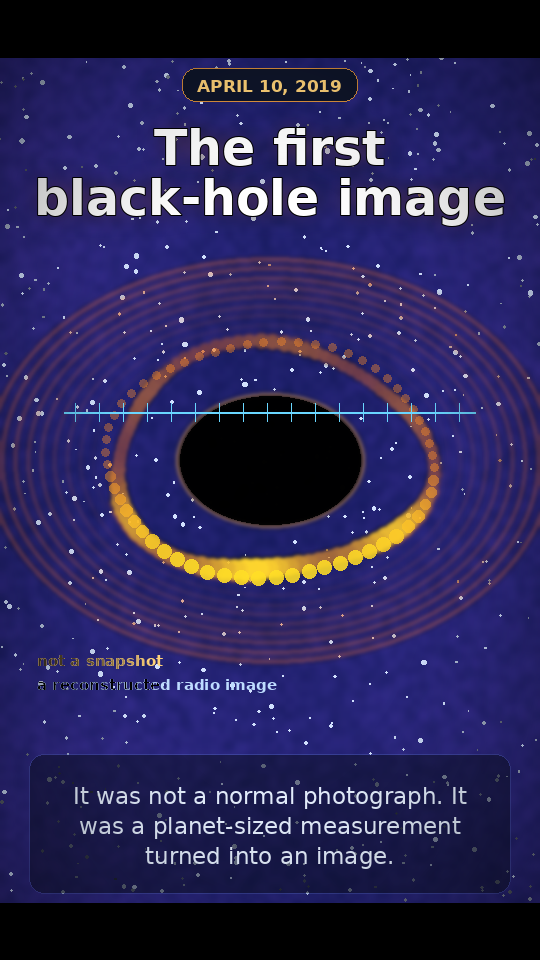

In [10]:
# ==========================
# Frame compositor
# ==========================
SCENE_FUNCS = {
    "hook": scene_hook,
    "target": scene_target,
    "scale": scene_scale,
    "array": scene_array,
    "wave": scene_wave,
    "clock": scene_clock,
    "data": scene_data,
    "correlation": scene_correlation,
    "uv": scene_uv,
    "reconstruct": scene_reconstruct,
    "meaning": scene_meaning,
}

def scene_for_time(t: float) -> tuple[dict, float]:
    for scene in SCENES:
        if scene["start"] <= t < scene["end"]:
            local = (t - scene["start"]) / (scene["end"] - scene["start"])
            return scene, clamp(local)
    scene = SCENES[-1]
    return scene, 1.0

def add_transition_wipe(img: Image.Image, local: float):
    # cinematic top/bottom curtain at scene boundaries
    edge = max(smoothstep(0.0, 0.06, local), smoothstep(1.0, 0.94, local))
    if edge <= 0:
        return
    d = ImageDraw.Draw(img, "RGBA")
    h = int(H * 0.06 * edge)
    d.rectangle([0, 0, W, h], fill=(0,0,0,int(160*edge)))
    d.rectangle([0, H-h, W, H], fill=(0,0,0,int(160*edge)))

def make_frame(frame_idx: int) -> np.ndarray:
    t = frame_idx / FPS
    scene, local = scene_for_time(t)

    # background changes subtly by scene
    bg = nebula_background(t, hue_shift=SCENES.index(scene) * 0.42)
    img = bg.convert("RGBA")

    # decorative scene number / technical grid
    grid = Image.new("RGBA", img.size, (0,0,0,0))
    gd = ImageDraw.Draw(grid, "RGBA")
    if scene["kind"] in {"array", "wave", "clock", "correlation", "uv", "reconstruct"}:
        step = max(36, W//12)
        for x in range(0, W, step):
            gd.line([x, 0, x, H], fill=(105,214,255,16), width=1)
        for y in range(0, H, step):
            gd.line([0, y, W, y], fill=(105,214,255,14), width=1)
        img.alpha_composite(grid)

    # visual
    SCENE_FUNCS[scene["kind"]](img, t, local)

    # global overlays
    draw_scene_text(img, scene, local)
    draw_progress(img, t)
    add_transition_wipe(img, local)
    add_vignette(img, 0.55)

    return np.array(img.convert("RGB"))

# Quick sanity preview of one frame
Image.fromarray(make_frame(int(2.0 * FPS)))


Saved storyboard preview: first_black_hole_image_output/First_Black_Hole_Image_Storyboard.png


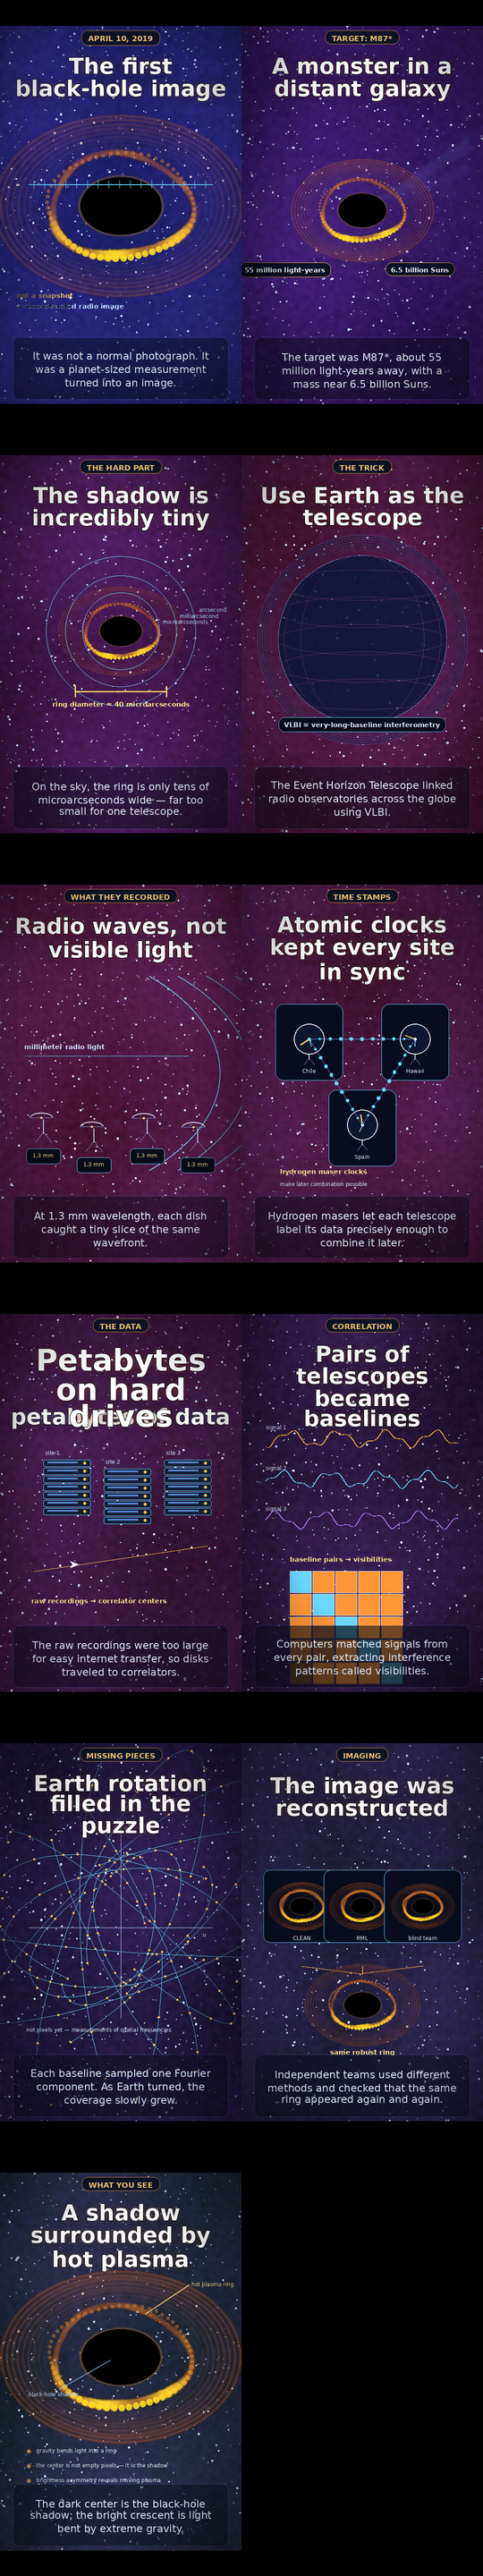

In [11]:
# ==========================
# Render storyboard preview
# ==========================
preview_times = [2.0, 10.5, 20.0, 29.0, 39.0, 48.0, 57.0, 66.5, 76.0, 84.0, 89.5]
frames = [Image.fromarray(make_frame(int(t * FPS))) for t in preview_times]

thumb_w = W // 2
thumb_h = H // 2
cols = 2
rows = math.ceil(len(frames) / cols)
contact = Image.new("RGB", (thumb_w * cols, thumb_h * rows), (0, 0, 0))
for idx, frame in enumerate(frames):
    thumb = frame.resize((thumb_w, thumb_h), Image.Resampling.LANCZOS)
    contact.paste(thumb, ((idx % cols) * thumb_w, (idx // cols) * thumb_h))

contact.save(STORYBOARD_NAME, quality=95)
print(f"Saved storyboard preview: {STORYBOARD_NAME}")
contact


In [12]:
# ==========================
# Render the full vertical video
# ==========================
# Tip: keep DRAFT_MODE=True for testing. Set DRAFT_MODE=False in the config cell for a sharper final export.
writer = imageio.get_writer(
    VIDEO_NAME,
    fps=FPS,
    codec="libx264",
    quality=8 if DRAFT_MODE else 9,
    pixelformat="yuv420p",
    macro_block_size=16,
)

for frame_idx in tqdm(range(NFRAMES), desc="Rendering first black-hole image explainer"):
    writer.append_data(make_frame(frame_idx))

writer.close()

print(f"Saved video: {VIDEO_NAME}")
print(f"Duration: {VIDEO_SECONDS:.1f}s | FPS: {FPS} | Size: {W}x{H}")


Rendering first black-hole image explainer:   0%|          | 0/1656 [00:00<?, ?it/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (540, 960) to (544, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved video: first_black_hole_image_output/First_Black_Hole_Image_Cinematic_Explainer.mp4
Duration: 92.0s | FPS: 18 | Size: 540x960


In [ ]:
# Display video inside the notebook, if supported
from IPython.display import Video, display

display(Video(str(VIDEO_NAME), embed=True, html_attributes="controls autoplay loop"))


## What this notebook explains

This video covers the actual pipeline behind the first black-hole image:

1. **Pick a target**: M87\*, a supermassive black hole in Messier 87.
2. **Solve the resolution problem**: one dish is too small, so the EHT used Earth-sized baselines.
3. **Record radio light**: telescopes observed at about **1.3 mm** wavelength.
4. **Synchronize timing**: sites used **hydrogen-maser atomic clocks**.
5. **Move the raw data**: enormous recordings were stored on hard drives and shipped to correlator centers.
6. **Correlate signals**: every telescope pair became a baseline that sampled Fourier-domain information.
7. **Calibrate and validate**: teams corrected atmospheric and instrumental errors.
8. **Reconstruct the image**: independent teams and algorithms checked that the ring was robust.
9. **Interpret the result**: the bright ring is hot plasma; the dark center is the black-hole shadow.

## Easy ways to customize

Edit only the `SCENES` list in the config cell to change the script timing and captions. The visuals are tied to each scene's `kind`, so the video stays cinematic even if you rewrite the text.

For a shorter Shorts-style version, set `VIDEO_SECONDS` to around 60 seconds and shorten the scene captions. For a more documentary style, increase scene durations and add more explanatory captions.


## Source notes

The built-in script is based on public educational and technical sources from the Event Horizon Telescope Collaboration, NASA, NASA/JPL, and the EHT 2019 technical papers:

- Event Horizon Telescope 2019 press release: `https://eventhorizontelescope.org/press-release-april-10-2019-astronomers-capture-first-image-black-hole`
- NASA image resource: `https://science.nasa.gov/resource/first-image-of-a-black-hole/`
- NASA/JPL classroom explainer: `https://www.jpl.nasa.gov/edu/resources/teachable-moment/how-scientists-captured-the-first-image-of-a-black-hole/`
- EHT science overview: `https://eventhorizontelescope.org/science`
- EHT Results II, Array and Instrumentation: `https://arxiv.org/abs/1906.11239`
- EHT Results III, Data Processing and Calibration: `https://arxiv.org/abs/1906.11240`
- EHT Results IV, Imaging: `https://arxiv.org/abs/1906.11241`
